In [1]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.163226,0.019855,0.008796,00:44


epoch,train_loss,valid_loss,error_rate,time
0,0.050890,0.016677,0.006089,00:56


In [2]:
import ipywidgets as widgets
uploader = widgets.FileUpload()
uploader

FileUpload(value={}, description='Upload')

In [4]:
img = PILImage.create(uploader.data[0])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: True.
Probability it's a cat: 1.000000


In [5]:
path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

learn = unet_learner(dls, resnet34)
learn.fine_tune(8)

epoch,train_loss,valid_loss,time
0,3.318255,2.656327,00:02


epoch,train_loss,valid_loss,time
0,2.067228,1.624198,00:01
1,1.715095,1.388417,00:01
2,1.489904,1.190086,00:01
3,1.291125,0.908607,00:01
4,1.139895,0.851470,00:01
5,1.016831,0.844420,00:01
6,0.919945,0.789725,00:01
7,0.847342,0.791598,00:01


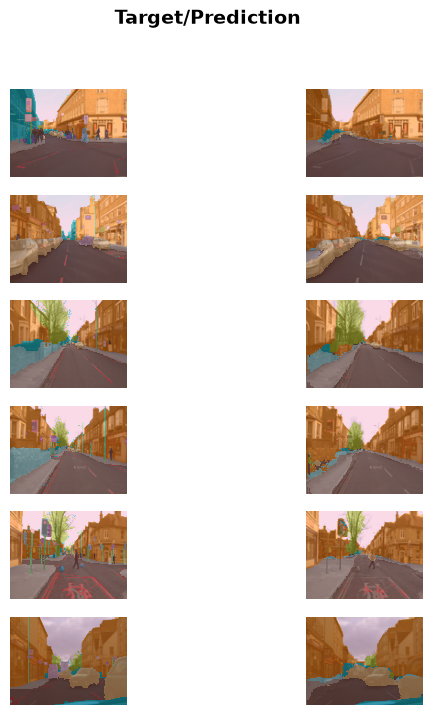

In [6]:
learn.show_results(max_n=6, figsize=(7,8))

In [ ]:
from fastai.text.all import *
dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

In [ ]:
learn.predict("I really liked that movie!")

In [7]:
from fastai.tabular.all import *
path = untar_data(URLs.ADULT_SAMPLE)

dls = TabularDataLoaders.from_csv(path/'adult.csv', path=path, y_names="salary",
    cat_names = ['workclass', 'education', 'marital-status', 'occupation',
                 'relationship', 'race'],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize])

learn = tabular_learner(dls, metrics=accuracy)
learn.fit_one_cycle(3)

<div><progress max="968212" value="974848"></progress> 100.69% [974848/968212 00:00&lt;00:00]</div>

/Users/kelinio/anaconda3/lib/python3.13/site-packages/fastai/tabular/core.py:314: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  to[n].fillna(self.na_dict[n], inplace=True)
/Users/kelinio/anaconda3/lib/python3.13/site-packages/fastai/torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support no

epoch,train_loss,valid_loss,accuracy,time
0,0.554408,0.545886,0.765356,00:05
1,0.548013,0.544892,0.765356,00:04
2,0.555215,0.545057,0.765356,00:04


In [8]:
from fastai.collab import *
path = untar_data(URLs.ML_SAMPLE)
dls = CollabDataLoaders.from_csv(path/'ratings.csv')
learn = collab_learner(dls, y_range=(0.5,5.5))
learn.fine_tune(10)

<div><progress max="51790" value="57344"></progress> 110.72% [57344/51790 00:00&lt;00:00]</div>

epoch,train_loss,valid_loss,time
0,1.519510,1.380123,00:01


epoch,train_loss,valid_loss,time
0,1.383641,1.321283,00:00
1,1.272372,1.144074,00:00
2,1.053977,0.839497,00:00
3,0.798459,0.704947,00:00
4,0.701817,0.669515,00:00
5,0.669437,0.656925,00:00
6,0.652269,0.652772,00:00
7,0.635632,0.650512,00:00
8,0.631826,0.649356,00:00
9,0.630153,0.649153,00:00


In [9]:
learn.show_results()

,userId,movieId,rating,rating_pred
0,21.0,11.0,3.0,3.288968
1,2.0,83.0,5.0,4.307646
2,7.0,16.0,4.0,4.079997
3,67.0,58.0,3.0,3.349756
4,84.0,71.0,3.0,3.633320
5,37.0,68.0,4.0,3.487748
6,4.0,75.0,4.0,4.103844
7,66.0,94.0,4.0,3.594123
8,1.0,82.0,4.0,3.799726
